In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold,GridSearchCV,RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline



we will use support vector machines, decision trees and random forests.

In [2]:
raw = pd.read_csv('iris.csv')

In [3]:
raw

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
raw.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
print(raw.duplicated().sum())

3


In [6]:
raw.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
raw.tail(50)

,sepal_length,sepal_width,petal_length,petal_width,species
100,6.3,3.3,6.0,2.5,Iris-virginica
101,5.8,2.7,5.1,1.9,Iris-virginica
102,7.1,3.0,5.9,2.1,Iris-virginica
103,6.3,2.9,5.6,1.8,Iris-virginica
104,6.5,3.0,5.8,2.2,Iris-virginica
105,7.6,3.0,6.6,2.1,Iris-virginica
106,4.9,2.5,4.5,1.7,Iris-virginica
107,7.3,2.9,6.3,1.8,Iris-virginica
108,6.7,2.5,5.8,1.8,Iris-virginica
109,7.2,3.6,6.1,2.5,Iris-virginica


In [8]:
raw.shape

(150, 5)

In [9]:
raw.info

<bound method DataFrame.info of      sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]>

In [10]:
raw.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
raw['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

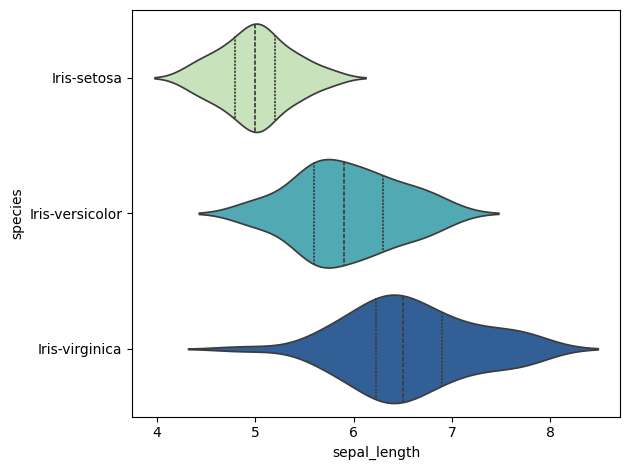

In [12]:
sns.violinplot(y='species', x='sepal_length', data=raw, inner='quartile', hue='species',palette="YlGnBu")
plt.tight_layout()

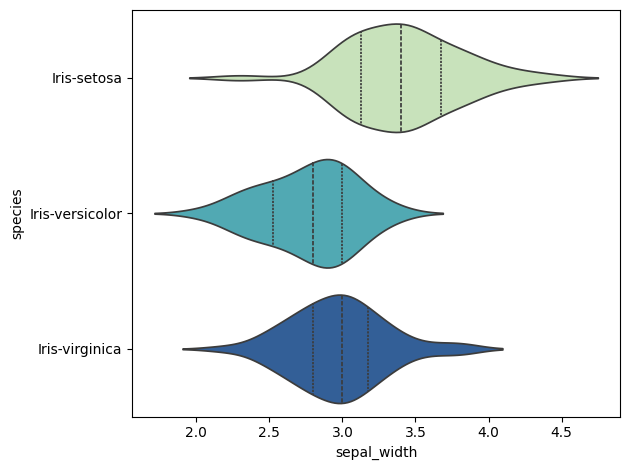

In [13]:
sns.violinplot(y='species', x='sepal_width',data=raw,inner='quartile', hue='species',palette="YlGnBu")
plt.tight_layout()

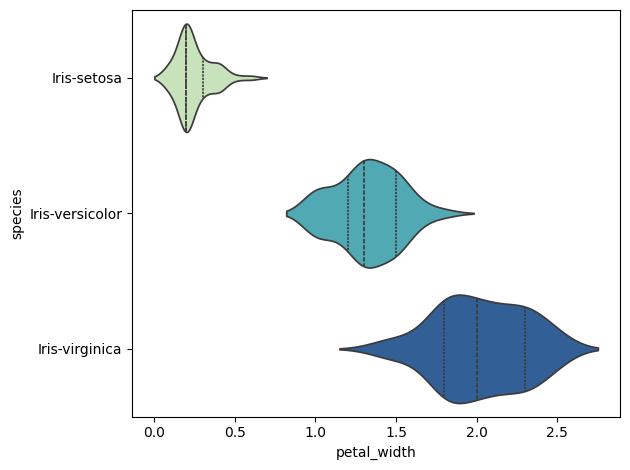

In [14]:
sns.violinplot(y='species', x='petal_width',data=raw,inner='quartile', hue='species',palette="YlGnBu")
plt.tight_layout()

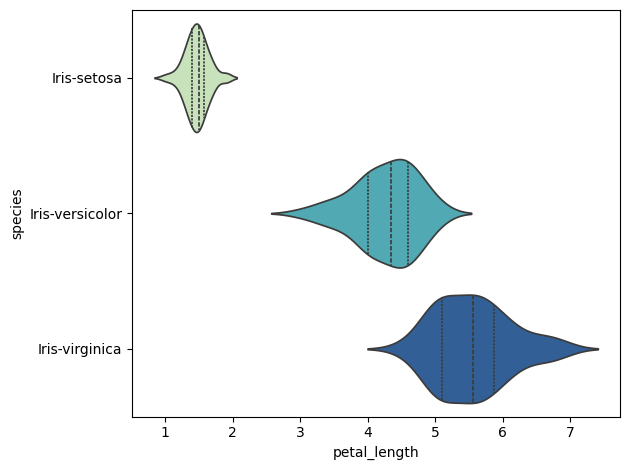

In [15]:
sns.violinplot(y='species', x='petal_length',data=raw,inner='quartile', hue='species',palette="YlGnBu")
plt.tight_layout()

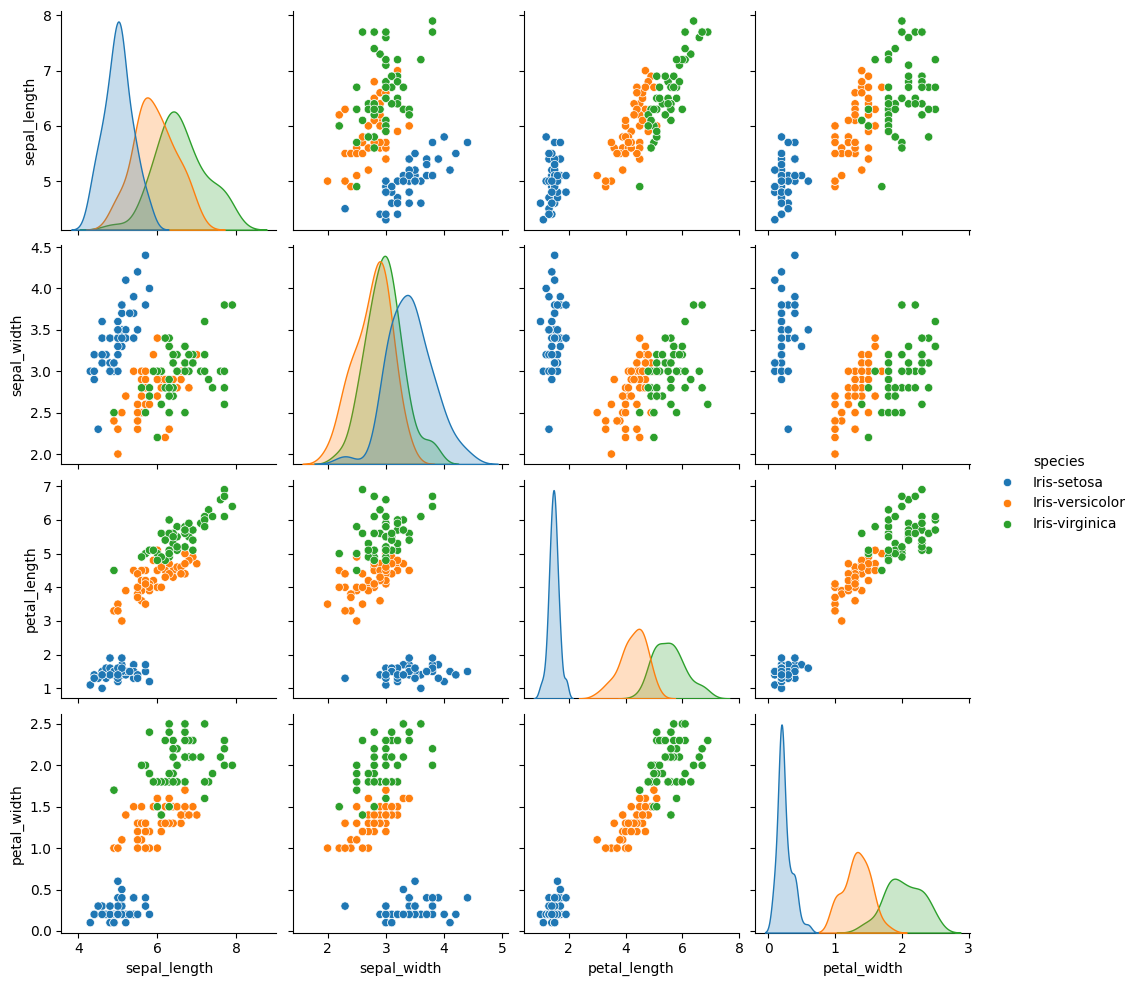

In [16]:
sns.pairplot(raw,hue='species')
plt.show()

<Axes: >

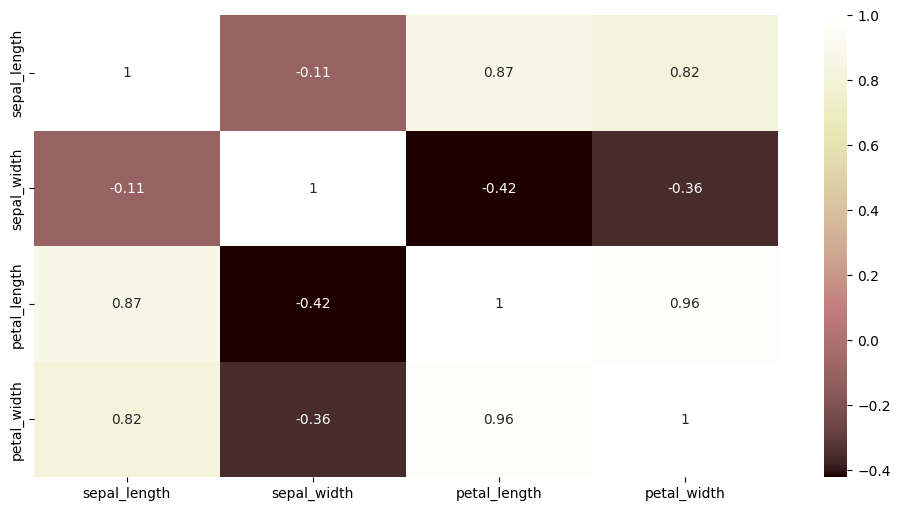

In [17]:
plt.figure(figsize=(12,6))
numerical_data = raw.select_dtypes(include=['float64','int64'])
sns.heatmap(numerical_data.corr(),annot=True, cmap='pink')

In [18]:
for i in raw.columns.tolist():
    print("No. of unique values in",i,"is",raw[i].nunique())

No. of unique values in sepal_length is 35
No. of unique values in sepal_width is 23
No. of unique values in petal_length is 43
No. of unique values in petal_width is 22
No. of unique values in species is 3


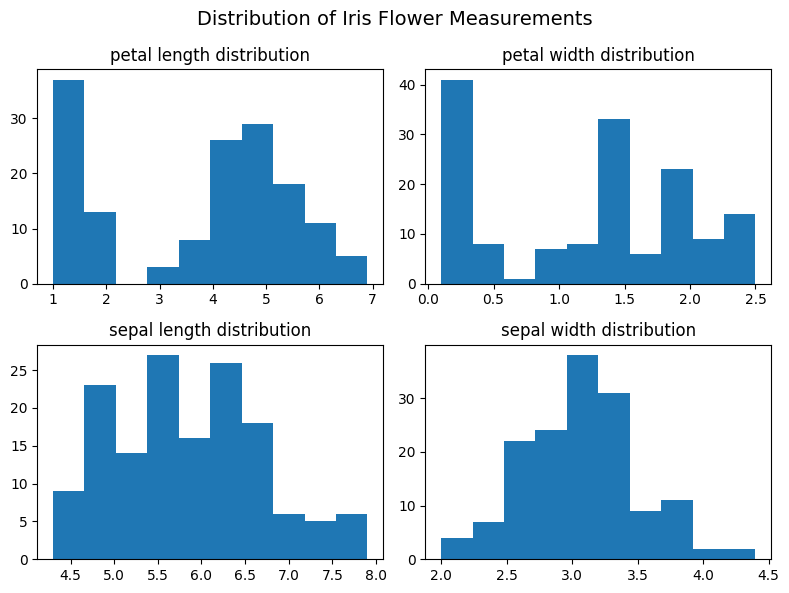

In [19]:
plt.figure(figsize=(8,6))
plt.suptitle('Distribution of Iris Flower Measurements', fontsize=14)

plt.subplot(2,2,1)
plt.hist(raw['petal_length'])
plt.title('petal length distribution')

plt.subplot(2,2,2)
plt.hist(raw['petal_width'])
plt.title('petal width distribution')

plt.subplot(2,2,3)
plt.hist(raw['sepal_length'])
plt.title('sepal length distribution')

plt.subplot(2,2,4)
plt.hist(raw['sepal_width'])
plt.title('sepal width distribution')

plt.tight_layout()  
plt.show()

In [20]:
colors = ['pink','blue','purple']
species = ['Iris-setosa','Iris-versicolor','Iris-virginica']

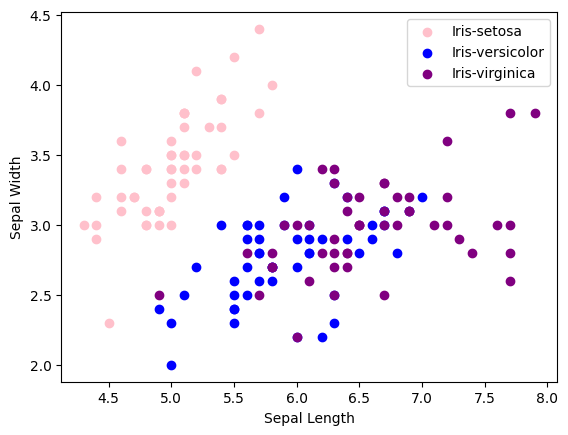

In [21]:
for i in range(3):
    x = raw[raw['species']==species[i]]
    plt.scatter(x['sepal_length'], x['sepal_width'],c=colors[i], label = species[i])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.show()



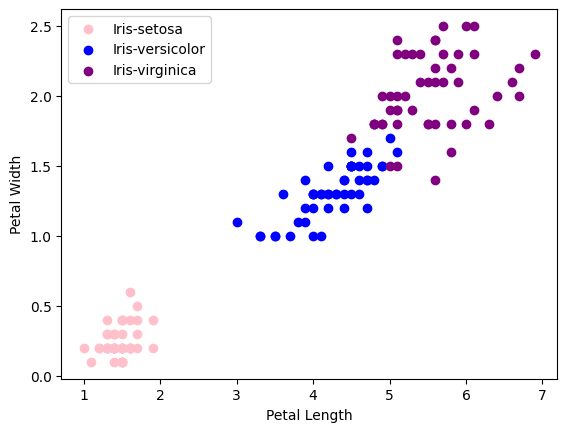

In [22]:
for i in range(3):
    x = raw[raw['species']==species[i]]
    plt.scatter(x['petal_length'], x['petal_width'],c=colors[i], label = species[i])
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()



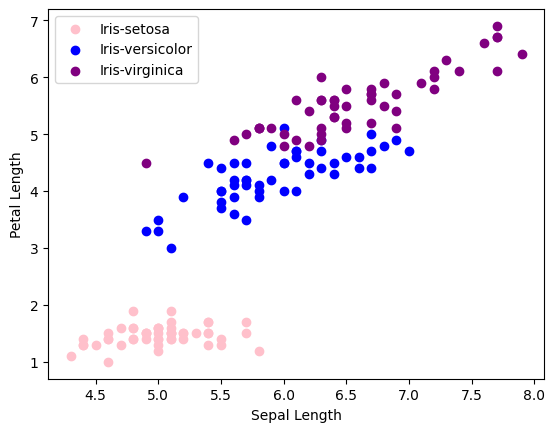

In [23]:
for i in range(3):
    x = raw[raw['species']==species[i]]
    plt.scatter(x['sepal_length'], x['petal_length'],c=colors[i], label = species[i])
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend()
plt.show()



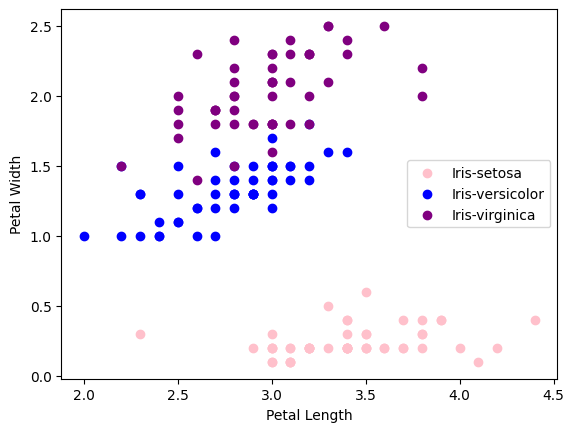

In [24]:
for i in range(3):
    x = raw[raw['species']==species[i]]
    plt.scatter(x['sepal_width'], x['petal_width'],c=colors[i], label = species[i])
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()



In [25]:


le = LabelEncoder()
raw['species']= le.fit_transform(raw['species'])

x=raw.drop(columns = ['species'],axis = 1)
y = raw['species']



In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [27]:
y_train

147    2
44     0
110    2
143    2
63     1
      ..
138    2
107    2
115    2
55     1
87     1
Name: species, Length: 105, dtype: int64

In [28]:
x_train

,sepal_length,sepal_width,petal_length,petal_width
147,6.5,3.0,5.2,2.0
44,5.1,3.8,1.9,0.4
110,6.5,3.2,5.1,2.0
143,6.8,3.2,5.9,2.3
63,6.1,2.9,4.7,1.4
...,...,...,...,...
138,6.0,3.0,4.8,1.8
107,7.3,2.9,6.3,1.8
115,6.4,3.2,5.3,2.3
55,5.7,2.8,4.5,1.3


In [29]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
    '''The function will take model, x train, x test, y train, y test
    and then it will fit the model, then make predictions on the trained model,
    it will then print roc-auc score of train and test, then plot the roc, auc curve,
    print confusion matrix for train and test, then print classification report for train and test,
    then plot the feature importances if the model has feature importances,
    and finally it will return the following scores as a list:
    recall_train, recall_test, acc_train, acc_test, F1_train, F1_test
    '''

    model.fit(x_train,y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    cm_train = confusion_matrix(y_train,y_pred_train)
    cm_test = confusion_matrix(y_test,y_pred_test)

    fig, ax = plt.subplots(1,2, figsize = (11,4))

    print("\nConfusion Matrix:")
    sns.heatmap(cm_train, annot=True, xticklabels=['Negative','Positive'],yticklabels=['Negative','Positive'],cmap="Oranges",fmt='.4g',ax=ax[0])
    ax[0].set_xlabel("Predicted label")
    ax[0].set_ylabel("True Label")
    ax[0].set_title("Train Confusion Matrix")

    sns.heatmap(cm_test, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[1])
    ax[1].set_xlabel("Predicted Label")
    ax[1].set_ylabel("True Label")
    ax[1].set_title("Test Confusion Matrix")

    plt.tight_layout()
    plt.show()

    cr_train = classification_report(y_train,y_pred_train,output_dict=True)
    cr_test = classification_report(y_test,y_pred_test,output_dict = True)
    print("\n Train Classification report:")
    crt = pd.DataFrame(cr_train).T
    print(crt.to_markdown())
    print("\n Test Classification report:")
    crt2 = pd.DataFrame(cr_test).T
    print(crt2.to_markdown())

    precision_train = cr_train['weighted avg']['precision']
    precision_test = cr_test['weighted avg']['precision']

    recall_train = cr_train['weighted avg']['recall']
    recall_test = cr_test['weighted avg']['recall']

    acc_train = accuracy_score(y_true = y_train, y_pred = y_pred_train)
    acc_test = accuracy_score(y_true = y_test, y_pred = y_pred_test)

    F1_train = cr_train['weighted avg']['f1-score']
    F1_test = cr_test['weighted avg']['f1-score']

    model_score = [precision_train, precision_test, recall_train, recall_test, acc_train, acc_test, F1_train, F1_test ]
    return model_score


    
    

    


In [30]:
score = pd.DataFrame(index = ['Precision Train','Precision Test','Recall Train','Recall Test','Accuracy Train', 'Accuracy Test', 'F1 macro Train', 'F1 macro Test'])

ML MODEL - 1 lOGISTIC REGRESSION

In [31]:
lr_model = LogisticRegression(fit_intercept = True, max_iter = 10000)


Confusion Matrix:


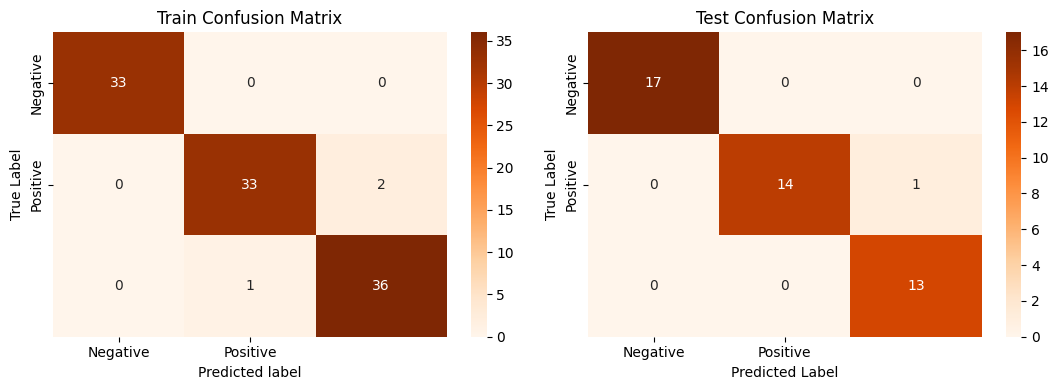


 Train Classification report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  33        |
| 1            |    0.970588 | 0.942857 |   0.956522 |  35        |
| 2            |    0.947368 | 0.972973 |   0.96     |  37        |
| accuracy     |    0.971429 | 0.971429 |   0.971429 |   0.971429 |
| macro avg    |    0.972652 | 0.971943 |   0.972174 | 105        |
| weighted avg |    0.97165  | 0.971429 |   0.971412 | 105        |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 17        |
| 1            |    1        | 0.933333 |   0.965517 | 15        |
| 2            |    0.928571 | 1        |   0.962963 | 13        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.97

In [32]:
lr_score = evaluate_model(lr_model,x_train,x_test,y_train,y_test)

In [33]:
score['Logistic Regression'] = lr_score
score

,Logistic Regression
Precision Train,0.971650
Precision Test,0.979365
Recall Train,0.971429
Recall Test,0.977778
Accuracy Train,0.971429
Accuracy Test,0.977778
F1 macro Train,0.971412
F1 macro Test,0.977806


In [34]:
param_grid = {'C': [100,10,1,0.1,0.01,0.001,0.0001],
              'penalty':['l1','l2'],
              'solver':['newton-cg','lbfgs','liblinear','sag','saga']}
logreg = LogisticRegression(fit_intercept = True, max_iter = 10000, random_state = 0)
rskf = RepeatedStratifiedKFold(n_splits = 3, n_repeats = 4, random_state = 0)
grid = GridSearchCV(logreg,param_grid,cv = rskf)
grid.fit(x_train,y_train)

best_params = grid.best_params_

print("Best hyperparameters: ", best_params)


Best hyperparameters:  {'C': 10, 'penalty': 'l2', 'solver': 'sag'}



Confusion Matrix:


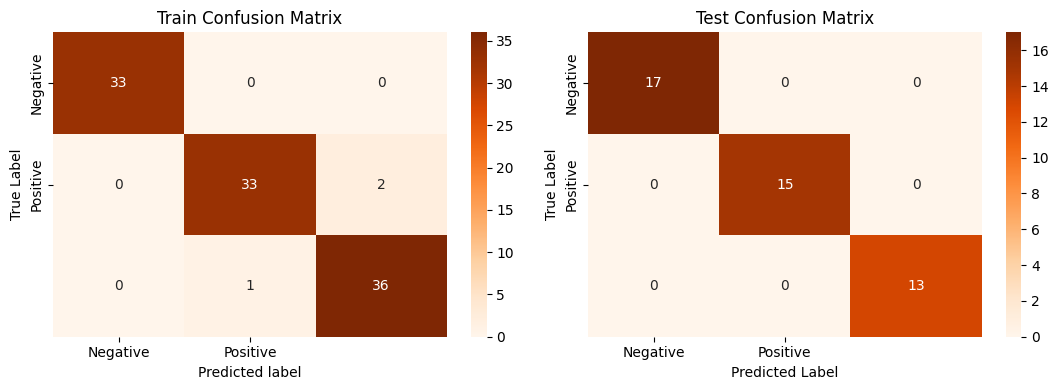


 Train Classification report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  33        |
| 1            |    0.970588 | 0.942857 |   0.956522 |  35        |
| 2            |    0.947368 | 0.972973 |   0.96     |  37        |
| accuracy     |    0.971429 | 0.971429 |   0.971429 |   0.971429 |
| macro avg    |    0.972652 | 0.971943 |   0.972174 | 105        |
| weighted avg |    0.97165  | 0.971429 |   0.971412 | 105        |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        17 |
| 1            |           1 |        1 |          1 |        15 |
| 2            |           1 |        1 |          1 |        13 |
| accuracy     |           1 |        1 |          1 |      

In [35]:
lr_model2 = LogisticRegression(C = best_params['C'],
                               penalty = best_params['penalty'],
                               solver = best_params['solver'],
                               max_iter = 10000,random_state = 0)

lr_score2 = evaluate_model(lr_model2,x_train,x_test,y_train,y_test)

In [36]:
score['Logistic regression tuned'] = lr_score2

Which hyperparameter optimization technique have i used and why?
The hyperparameter optimization technique used is GridSearchCV. GridSearchCV is a method that performs an exhaustive search over a specified parameter grid to find the best hyperparameters for a model. It is a popular method for hyperparameter tuning because it is simple to implement and can be effective in finding good hyperparameters for a model.

The choice of hyperparameter optimization technique depends on various factors such as the size of the parameter space, the computational resources available, and the time constraints. GridSearchCV can be a good choice when the parameter space is relatively small and computational resources are not a major concern.

In [37]:
score

,Logistic Regression,Logistic regression tuned
Precision Train,0.971650,0.971650
Precision Test,0.979365,1.000000
Recall Train,0.971429,0.971429
Recall Test,0.977778,1.000000
Accuracy Train,0.971429,0.971429
Accuracy Test,0.977778,1.000000
F1 macro Train,0.971412,0.971412
F1 macro Test,0.977806,1.000000



It appears that hyperparameter tuning did not improve the performance of the Logistic Regression model on the test set. The precision, recall, accuracy and F1 scores on the test set are same for both tuned and untuned Logistic Regression models.

#ML Model - 2 : Decision Tree


Confusion Matrix:


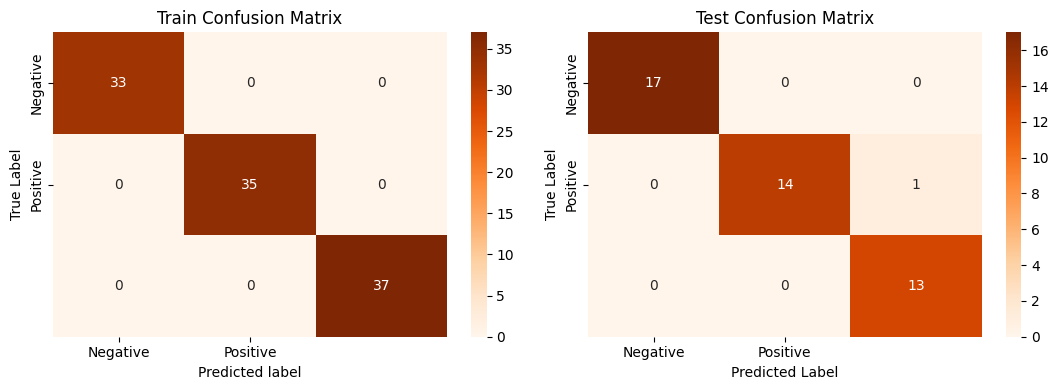


 Train Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        33 |
| 1            |           1 |        1 |          1 |        35 |
| 2            |           1 |        1 |          1 |        37 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       105 |
| weighted avg |           1 |        1 |          1 |       105 |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 17        |
| 1            |    1        | 0.933333 |   0.965517 | 15        |
| 2            |    0.928571 | 1        |   0.962963 | 13        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.977778 |
|

In [38]:
dt_model = DecisionTreeClassifier(random_state=20)
dt_score = evaluate_model(dt_model,x_train,x_test,y_train,y_test)

In [39]:
score['decision Tree'] = dt_score
score

,Logistic Regression,Logistic regression tuned,decision Tree
Precision Train,0.971650,0.971650,1.000000
Precision Test,0.979365,1.000000,0.979365
Recall Train,0.971429,0.971429,1.000000
Recall Test,0.977778,1.000000,0.977778
Accuracy Train,0.971429,0.971429,1.000000
Accuracy Test,0.977778,1.000000,0.977778
F1 macro Train,0.971412,0.971412,1.000000
F1 macro Test,0.977806,1.000000,0.977806


cross validation and hypertuning

In [40]:
grid = {
    'max_depth': [3,4,5,6,7,8],
    'min_samples_split':np.arange(2,8),
    'min_samples_leaf':np.arange(10,20)
}

model = DecisionTreeClassifier()

rskf = RepeatedStratifiedKFold(n_splits =3,n_repeats = 3,random_state = 0)

grid_search = GridSearchCV(model,grid,cv=rskf)

grid_search.fit(x_train,y_train)
best_params = grid_search.best_params_
print("Best hyperparameters: ", best_params)

Best hyperparameters:  {'max_depth': 3, 'min_samples_leaf': np.int64(10), 'min_samples_split': np.int64(5)}


In [41]:
dt_model2 = DecisionTreeClassifier(max_depth = best_params['max_depth'],
                                   min_samples_leaf = best_params['min_samples_leaf'],
                                   min_samples_split = best_params['min_samples_split'],
                                   random_state = 20)


Confusion Matrix:


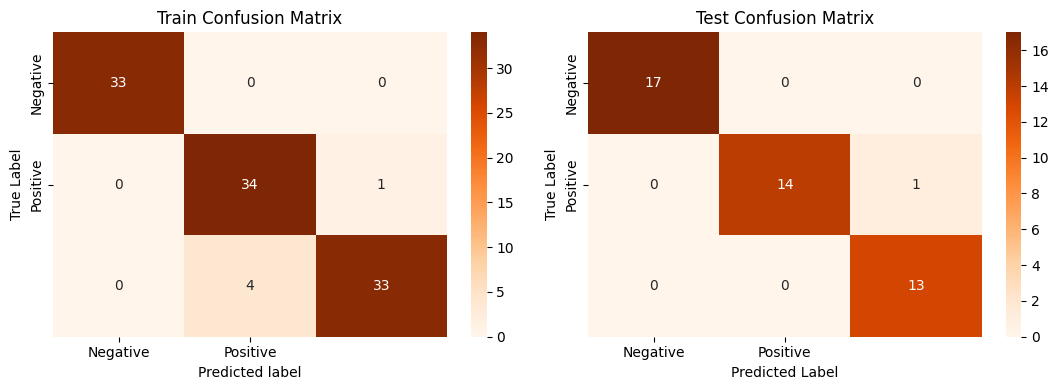


 Train Classification report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  33        |
| 1            |    0.894737 | 0.971429 |   0.931507 |  35        |
| 2            |    0.970588 | 0.891892 |   0.929577 |  37        |
| accuracy     |    0.952381 | 0.952381 |   0.952381 |   0.952381 |
| macro avg    |    0.955108 | 0.95444  |   0.953695 | 105        |
| weighted avg |    0.954548 | 0.952381 |   0.952353 | 105        |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 17        |
| 1            |    1        | 0.933333 |   0.965517 | 15        |
| 2            |    0.928571 | 1        |   0.962963 | 13        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.97

In [42]:
dt2_score = evaluate_model(dt_model2,x_train,x_test,y_train,y_test)

In [43]:
score

,Logistic Regression,Logistic regression tuned,decision Tree
Precision Train,0.971650,0.971650,1.000000
Precision Test,0.979365,1.000000,0.979365
Recall Train,0.971429,0.971429,1.000000
Recall Test,0.977778,1.000000,0.977778
Accuracy Train,0.971429,0.971429,1.000000
Accuracy Test,0.977778,1.000000,0.977778
F1 macro Train,0.971412,0.971412,1.000000
F1 macro Test,0.977806,1.000000,0.977806


In [44]:
score['decision tree tuned'] = dt2_score

#ML MODEL - 3 RANDOM FOREST

In [45]:
rf_model = RandomForestClassifier(random_state = 0)


Confusion Matrix:


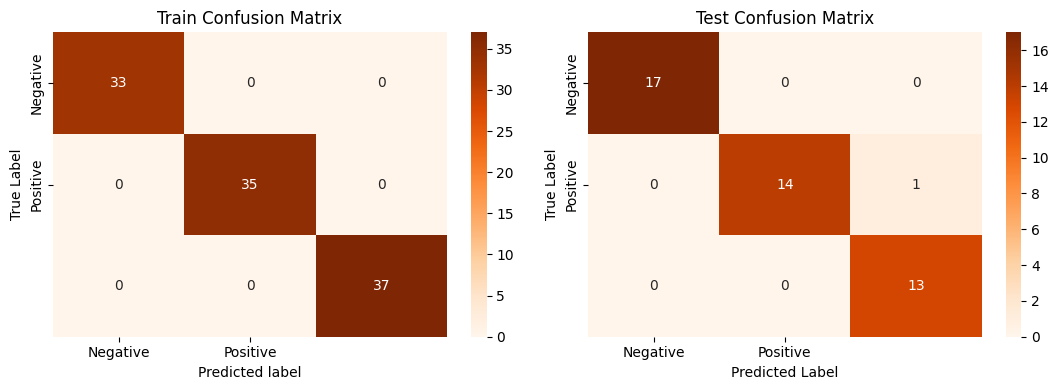


 Train Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        33 |
| 1            |           1 |        1 |          1 |        35 |
| 2            |           1 |        1 |          1 |        37 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       105 |
| weighted avg |           1 |        1 |          1 |       105 |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 17        |
| 1            |    1        | 0.933333 |   0.965517 | 15        |
| 2            |    0.928571 | 1        |   0.962963 | 13        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.977778 |
|

In [46]:
rf_score = evaluate_model(rf_model,x_train,x_test,y_train,y_test)

In [47]:
score['Random Forest']=rf_score

In [48]:
score

,Logistic Regression,Logistic regression tuned,decision Tree,decision tree tuned,Random Forest
Precision Train,0.971650,0.971650,1.000000,0.954548,1.000000
Precision Test,0.979365,1.000000,0.979365,0.979365,0.979365
Recall Train,0.971429,0.971429,1.000000,0.952381,1.000000
Recall Test,0.977778,1.000000,0.977778,0.977778,0.977778
Accuracy Train,0.971429,0.971429,1.000000,0.952381,1.000000
Accuracy Test,0.977778,1.000000,0.977778,0.977778,0.977778
F1 macro Train,0.971412,0.971412,1.000000,0.952353,1.000000
F1 macro Test,0.977806,1.000000,0.977806,0.977806,0.977806


cross validation and hyperparameter tuning

In [49]:
grid = {'n_estimators': [10,50,100,200],
        'max_depth':[8,9,10,11,12,13,14,15],
        'min_samples_split':[2,3,4,5]}
rf = RandomForestClassifier(random_state = 0)

rskf = RepeatedStratifiedKFold(n_splits = 3,n_repeats = 3,random_state = 0)

random_search = RandomizedSearchCV(rf,grid,cv=rskf,n_iter=10,n_jobs=-1)
random_search.fit(x_train,y_train)

best_params = random_search.best_params_
print("Best hyperparameters: ", best_params)


Best hyperparameters:  {'n_estimators': 100, 'min_samples_split': 4, 'max_depth': 15}


In [50]:
rf_model2 = RandomForestClassifier(n_estimators = best_params['n_estimators'],
                                 min_samples_leaf= best_params['min_samples_split'],
                                 max_depth = best_params['max_depth'],
                                 random_state=0)


Confusion Matrix:


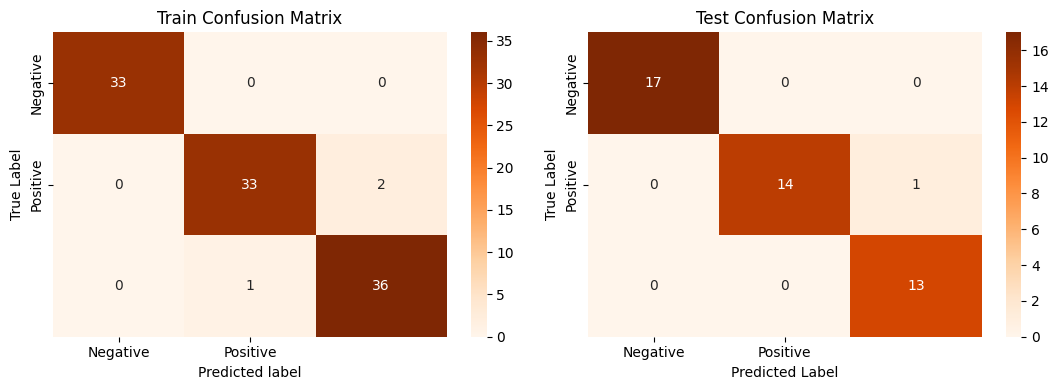


 Train Classification report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  33        |
| 1            |    0.970588 | 0.942857 |   0.956522 |  35        |
| 2            |    0.947368 | 0.972973 |   0.96     |  37        |
| accuracy     |    0.971429 | 0.971429 |   0.971429 |   0.971429 |
| macro avg    |    0.972652 | 0.971943 |   0.972174 | 105        |
| weighted avg |    0.97165  | 0.971429 |   0.971412 | 105        |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 17        |
| 1            |    1        | 0.933333 |   0.965517 | 15        |
| 2            |    0.928571 | 1        |   0.962963 | 13        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.97

In [51]:
rf2_score = evaluate_model(rf_model2, x_train, x_test, y_train, y_test)

In [52]:
score['Random Forest tuned'] = rf2_score

In [53]:
score

,Logistic Regression,Logistic regression tuned,decision Tree,decision tree tuned,Random Forest,Random Forest tuned
Precision Train,0.971650,0.971650,1.000000,0.954548,1.000000,0.971650
Precision Test,0.979365,1.000000,0.979365,0.979365,0.979365,0.979365
Recall Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429
Recall Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778
Accuracy Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429
Accuracy Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778
F1 macro Train,0.971412,0.971412,1.000000,0.952353,1.000000,0.971412
F1 macro Test,0.977806,1.000000,0.977806,0.977806,0.977806,0.977806


It appears that hyperparameter tuning improved the performance of the Random Forest model on the train set. But the precision, recall, accuracy and F1 scores on the test set are same for both tuned and untuned Random Forest models.

#ML MODEL 4 SVM

In [54]:
svm_model = SVC(kernel = 'linear', random_state = 0,probability = True)


Confusion Matrix:


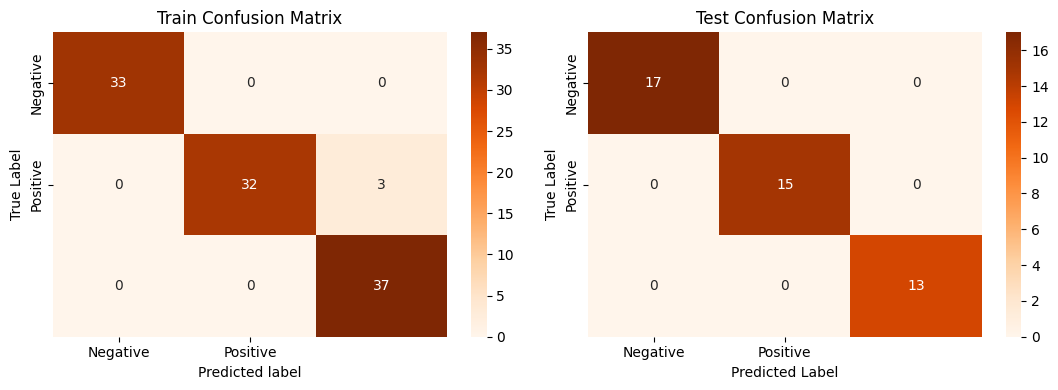


 Train Classification report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  33        |
| 1            |    1        | 0.914286 |   0.955224 |  35        |
| 2            |    0.925    | 1        |   0.961039 |  37        |
| accuracy     |    0.971429 | 0.971429 |   0.971429 |   0.971429 |
| macro avg    |    0.975    | 0.971429 |   0.972088 | 105        |
| weighted avg |    0.973571 | 0.971429 |   0.971345 | 105        |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        17 |
| 1            |           1 |        1 |          1 |        15 |
| 2            |           1 |        1 |          1 |        13 |
| accuracy     |           1 |        1 |          1 |      

In [55]:
svm_score = evaluate_model(svm_model, x_train, x_test, y_train, y_test)

In [56]:
score['SVM']= svm_score

In [57]:
score

,Logistic Regression,Logistic regression tuned,decision Tree,decision tree tuned,Random Forest,Random Forest tuned,SVM
Precision Train,0.971650,0.971650,1.000000,0.954548,1.000000,0.971650,0.973571
Precision Test,0.979365,1.000000,0.979365,0.979365,0.979365,0.979365,1.000000
Recall Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429
Recall Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000
Accuracy Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429
Accuracy Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000
F1 macro Train,0.971412,0.971412,1.000000,0.952353,1.000000,0.971412,0.971345
F1 macro Test,0.977806,1.000000,0.977806,0.977806,0.977806,0.977806,1.000000


In [58]:
param_grid = {'C': np.arange(0.1, 10, 0.1),
              'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
              'degree': np.arange(2, 6, 1)}

# Initialize the model
svm = SVC(random_state=0, probability=True)

# Repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

# Initialize RandomizedSearchCV with kfold cross-validation
random_search = RandomizedSearchCV(svm, param_grid, n_iter=10, cv=rskf, n_jobs=-1)

# Fit the RandomizedSearchCV to the training data
random_search.fit(x_train, y_train)

# Select the best hyperparameters
best_params = random_search.best_params_
print("Best hyperparameters: ", best_params)

Best hyperparameters:  {'kernel': 'rbf', 'degree': np.int64(4), 'C': np.float64(6.2)}


In [59]:
svm_model2 = SVC(C = best_params['C'],
           kernel = best_params['kernel'],
           degree = best_params['degree'],
           random_state=0, probability=True)


Confusion Matrix:


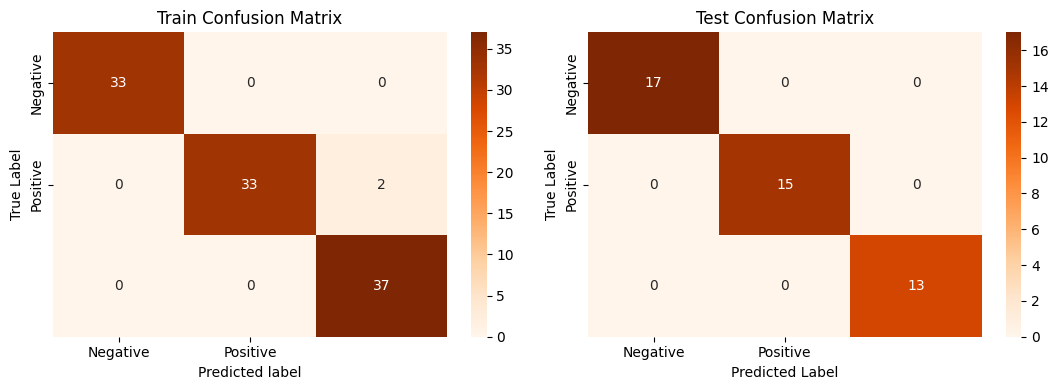


 Train Classification report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  33        |
| 1            |    1        | 0.942857 |   0.970588 |  35        |
| 2            |    0.948718 | 1        |   0.973684 |  37        |
| accuracy     |    0.980952 | 0.980952 |   0.980952 |   0.980952 |
| macro avg    |    0.982906 | 0.980952 |   0.981424 | 105        |
| weighted avg |    0.981929 | 0.980952 |   0.980923 | 105        |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        17 |
| 1            |           1 |        1 |          1 |        15 |
| 2            |           1 |        1 |          1 |        13 |
| accuracy     |           1 |        1 |          1 |      

In [60]:

# Visualizing evaluation Metric Score chart
svm2_score = evaluate_model(svm_model2, x_train, x_test, y_train, y_test)

In [61]:
score['SVM TUNED'] = svm2_score

In [62]:
score

,Logistic Regression,Logistic regression tuned,decision Tree,decision tree tuned,Random Forest,Random Forest tuned,SVM,SVM TUNED
Precision Train,0.971650,0.971650,1.000000,0.954548,1.000000,0.971650,0.973571,0.981929
Precision Test,0.979365,1.000000,0.979365,0.979365,0.979365,0.979365,1.000000,1.000000
Recall Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429,0.980952
Recall Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000,1.000000
Accuracy Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429,0.980952
Accuracy Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000,1.000000
F1 macro Train,0.971412,0.971412,1.000000,0.952353,1.000000,0.971412,0.971345,0.980923
F1 macro Test,0.977806,1.000000,0.977806,0.977806,0.977806,0.977806,1.000000,1.000000


#ML MODEL 5 NAIVE BAYES

In [63]:
nb_model = GaussianNB()


Confusion Matrix:


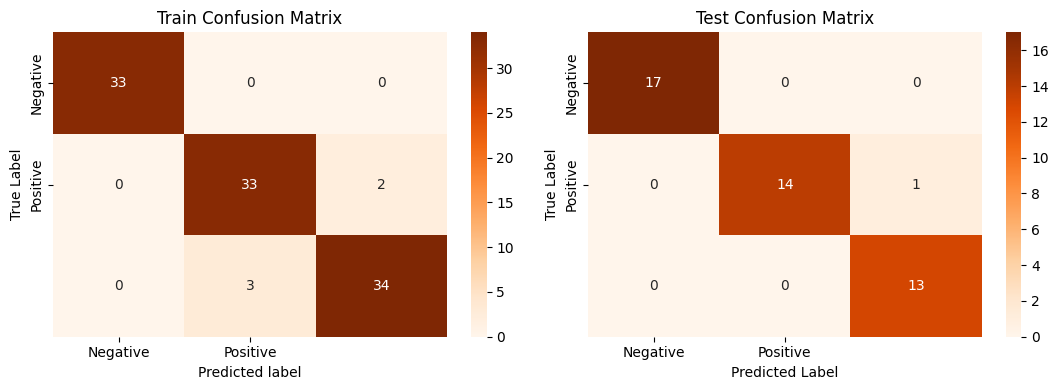


 Train Classification report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  33        |
| 1            |    0.916667 | 0.942857 |   0.929577 |  35        |
| 2            |    0.944444 | 0.918919 |   0.931507 |  37        |
| accuracy     |    0.952381 | 0.952381 |   0.952381 |   0.952381 |
| macro avg    |    0.953704 | 0.953925 |   0.953695 | 105        |
| weighted avg |    0.952646 | 0.952381 |   0.95239  | 105        |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 17        |
| 1            |    1        | 0.933333 |   0.965517 | 15        |
| 2            |    0.928571 | 1        |   0.962963 | 13        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.97

In [64]:
nb_score = evaluate_model(nb_model, x_train,x_test,y_train,y_test)

In [65]:
score['Naive bayes'] = nb_score

In [66]:
score

,Logistic Regression,Logistic regression tuned,decision Tree,decision tree tuned,Random Forest,Random Forest tuned,SVM,SVM TUNED,Naive bayes
Precision Train,0.971650,0.971650,1.000000,0.954548,1.000000,0.971650,0.973571,0.981929,0.952646
Precision Test,0.979365,1.000000,0.979365,0.979365,0.979365,0.979365,1.000000,1.000000,0.979365
Recall Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429,0.980952,0.952381
Recall Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000,1.000000,0.977778
Accuracy Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429,0.980952,0.952381
Accuracy Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000,1.000000,0.977778
F1 macro Train,0.971412,0.971412,1.000000,0.952353,1.000000,0.971412,0.971345,0.980923,0.952390
F1 macro Test,0.977806,1.000000,0.977806,0.977806,0.977806,0.977806,1.000000,1.000000,0.977806


cross validation and hyperparamter tuning

In [67]:
param_grid = {'var_smoothing': np.logspace(0,-9, num=100)}

naive = GaussianNB()

rskf = RepeatedStratifiedKFold(n_splits = 4,n_repeats = 4, random_state=0)
GridSearch = GridSearchCV(naive, param_grid, cv = rskf, n_jobs=-1)
GridSearch.fit(x_train,y_train)
best_params = GridSearch.best_params_
print("Best hyperparamters: ", best_params)

Best hyperparamters:  {'var_smoothing': np.float64(0.004328761281083057)}


In [68]:
nn_model = MLPClassifier(random_state=0)


Confusion Matrix:


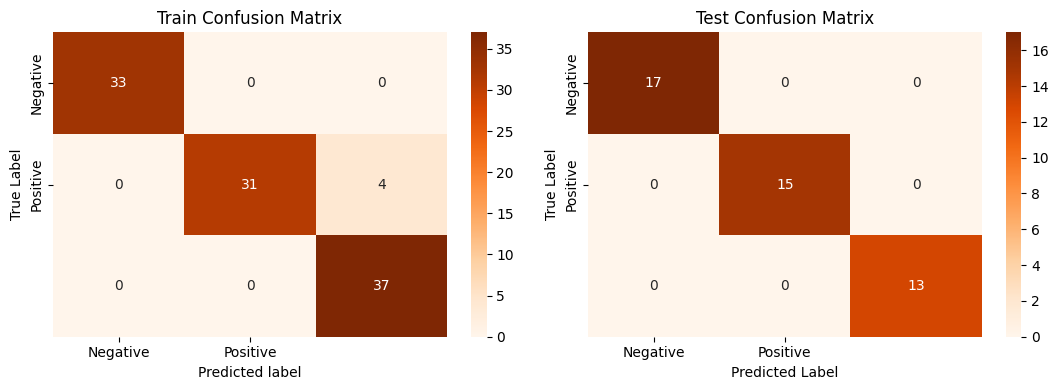


 Train Classification report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  33        |
| 1            |    1        | 0.885714 |   0.939394 |  35        |
| 2            |    0.902439 | 1        |   0.948718 |  37        |
| accuracy     |    0.961905 | 0.961905 |   0.961905 |   0.961905 |
| macro avg    |    0.96748  | 0.961905 |   0.962704 | 105        |
| weighted avg |    0.965621 | 0.961905 |   0.961727 | 105        |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        17 |
| 1            |           1 |        1 |          1 |        15 |
| 2            |           1 |        1 |          1 |        13 |
| accuracy     |           1 |        1 |          1 |      

In [69]:
neural_score = evaluate_model(nn_model,x_train,x_test,y_train,y_test)

In [70]:
score['Neural Network']=neural_score

In [71]:
score

,Logistic Regression,Logistic regression tuned,decision Tree,decision tree tuned,Random Forest,Random Forest tuned,SVM,SVM TUNED,Naive bayes,Neural Network
Precision Train,0.971650,0.971650,1.000000,0.954548,1.000000,0.971650,0.973571,0.981929,0.952646,0.965621
Precision Test,0.979365,1.000000,0.979365,0.979365,0.979365,0.979365,1.000000,1.000000,0.979365,1.000000
Recall Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429,0.980952,0.952381,0.961905
Recall Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000,1.000000,0.977778,1.000000
Accuracy Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429,0.980952,0.952381,0.961905
Accuracy Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000,1.000000,0.977778,1.000000
F1 macro Train,0.971412,0.971412,1.000000,0.952353,1.000000,0.971412,0.971345,0.980923,0.952390,0.961727
F1 macro Test,0.977806,1.000000,0.977806,0.977806,0.977806,0.977806,1.000000,1.000000,0.977806,1.000000


In [72]:
param_grid = {'hidden_layer_sizes': np.arange(10, 100, 10),
              'alpha': np.arange(0.0001, 0.01, 0.0001)}

# Initialize the model
neural = MLPClassifier(random_state=0)

# Repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(neural, param_grid, n_iter=10, cv=rskf, n_jobs=-1)

# Fit the RandomizedSearchCV to the training data
random_search.fit(x_train, y_train)

# Select the best hyperparameters
best_params = random_search.best_params_
print("Best hyperparameters: ", best_params)

Best hyperparameters:  {'hidden_layer_sizes': np.int64(80), 'alpha': np.float64(0.0017000000000000001)}


In [73]:
nn_model2 = MLPClassifier(hidden_layer_sizes = best_params['hidden_layer_sizes'],
                        alpha = best_params['alpha'],
                        random_state = 0)
     


Confusion Matrix:


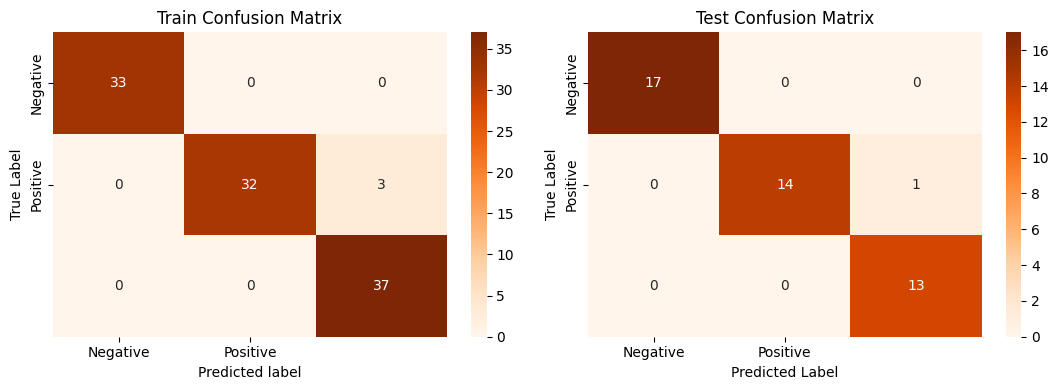


 Train Classification report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  33        |
| 1            |    1        | 0.914286 |   0.955224 |  35        |
| 2            |    0.925    | 1        |   0.961039 |  37        |
| accuracy     |    0.971429 | 0.971429 |   0.971429 |   0.971429 |
| macro avg    |    0.975    | 0.971429 |   0.972088 | 105        |
| weighted avg |    0.973571 | 0.971429 |   0.971345 | 105        |

 Test Classification report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 17        |
| 1            |    1        | 0.933333 |   0.965517 | 15        |
| 2            |    0.928571 | 1        |   0.962963 | 13        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.97

In [74]:
neural2_score = evaluate_model(nn_model2, x_train, x_test, y_train, y_test)

In [75]:
score['Neural Network tuned']= neural2_score
score

,Logistic Regression,Logistic regression tuned,decision Tree,decision tree tuned,Random Forest,Random Forest tuned,SVM,SVM TUNED,Naive bayes,Neural Network,Neural Network tuned
Precision Train,0.971650,0.971650,1.000000,0.954548,1.000000,0.971650,0.973571,0.981929,0.952646,0.965621,0.973571
Precision Test,0.979365,1.000000,0.979365,0.979365,0.979365,0.979365,1.000000,1.000000,0.979365,1.000000,0.979365
Recall Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429,0.980952,0.952381,0.961905,0.971429
Recall Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000,1.000000,0.977778,1.000000,0.977778
Accuracy Train,0.971429,0.971429,1.000000,0.952381,1.000000,0.971429,0.971429,0.980952,0.952381,0.961905,0.971429
Accuracy Test,0.977778,1.000000,0.977778,0.977778,0.977778,0.977778,1.000000,1.000000,0.977778,1.000000,0.977778
F1 macro Train,0.971412,0.971412,1.000000,0.952353,1.000000,0.971412,0.971345,0.980923,0.952390,0.961727,0.971345
F1 macro Test,0.977806,1.000000,0.977806,0.977806,0.977806,0.977806,1.000000,1.000000,0.977806,1.000000,0.977806


In [76]:
print(score.to_markdown())

|                 |   Logistic Regression |   Logistic regression tuned |   decision Tree |   decision tree tuned |   Random Forest |   Random Forest tuned |      SVM |   SVM TUNED |   Naive bayes |   Neural Network |   Neural Network tuned |
|:----------------|----------------------:|----------------------------:|----------------:|----------------------:|----------------:|----------------------:|---------:|------------:|--------------:|-----------------:|-----------------------:|
| Precision Train |              0.97165  |                    0.97165  |        1        |              0.954548 |        1        |              0.97165  | 0.973571 |    0.981929 |      0.952646 |         0.965621 |               0.973571 |
| Precision Test  |              0.979365 |                    1        |        0.979365 |              0.979365 |        0.979365 |              0.979365 | 1        |    1        |      0.979365 |         1        |               0.979365 |
| Recall Train    |         

Selection of best model

In [77]:
# Removing the overfitted models which have precision, recall, f1 scores for train as 1
score_t = score.transpose()            # taking transpose of the score dataframe to create new difference column
remove_models = score_t[score_t['Recall Train']>=0.98].index  # creating a list of models which have 1 for train and score_t['Accuracy Train']==1.0 and score_t['Precision Train']==1.0 and score_t['F1 macro Train']==1.0
remove_models

adj = score_t.drop(remove_models)                     # creating a new dataframe with required models
adj

,Precision Train,Precision Test,Recall Train,Recall Test,Accuracy Train,Accuracy Test,F1 macro Train,F1 macro Test
Logistic Regression,0.971650,0.979365,0.971429,0.977778,0.971429,0.977778,0.971412,0.977806
Logistic regression tuned,0.971650,1.000000,0.971429,1.000000,0.971429,1.000000,0.971412,1.000000
decision tree tuned,0.954548,0.979365,0.952381,0.977778,0.952381,0.977778,0.952353,0.977806
Random Forest tuned,0.971650,0.979365,0.971429,0.977778,0.971429,0.977778,0.971412,0.977806
SVM,0.973571,1.000000,0.971429,1.000000,0.971429,1.000000,0.971345,1.000000
Naive bayes,0.952646,0.979365,0.952381,0.977778,0.952381,0.977778,0.952390,0.977806
Neural Network,0.965621,1.000000,0.961905,1.000000,0.961905,1.000000,0.961727,1.000000
Neural Network tuned,0.973571,0.979365,0.971429,0.977778,0.971429,0.977778,0.971345,0.977806


In [78]:
def select_best_model(df, metrics):

    best_models = {}
    for metric in metrics:
        max_test = df[metric + ' Test'].max()
        best_model_test = df[df[metric + ' Test'] == max_test].index[0]
        best_model = best_model_test
        best_models[metric] = best_model
    return best_models

In [79]:
metrics = ['Precision', 'Recall', 'Accuracy', 'F1 macro']

best_models = select_best_model(adj, metrics)
print("The best models are:")
for metric, best_model in best_models.items():
    print(f"{metric}: {best_model} - {adj[metric+' Test'][best_model].round(4)}")

The best models are:
Precision: Logistic regression tuned - 1.0
Recall: Logistic regression tuned - 1.0
Accuracy: Logistic regression tuned - 1.0
F1 macro: Logistic regression tuned - 1.0


In [80]:
adj.columns

Index(['Precision Train', 'Precision Test', 'Recall Train', 'Recall Test',
       'Accuracy Train', 'Accuracy Test', 'F1 macro Train', 'F1 macro Test'],
      dtype='object')

In [81]:
score_smpl = score.transpose()
remove_overfitting_models = score_smpl[score_smpl['Recall Train']>=0.98].index
remove_overfitting_models
new_score = score_smpl.drop(remove_overfitting_models)
new_score = new_score.drop(['Precision Train', 'Precision Test', 'Recall Train', 'Recall Test',
       'Accuracy Train', 'Accuracy Test', 'F1 macro Train', 'F1 macro Test'], axis=1)
new_score.index.name = 'Classification Model'
print(new_score.to_markdown())
     

| Classification Model      |
|:--------------------------|
| Logistic Regression       |
| Logistic regression tuned |
| decision tree tuned       |
| Random Forest tuned       |
| SVM                       |
| Naive bayes               |
| Neural Network            |
| Neural Network tuned      |


In [82]:
Category_RF = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

In [83]:
x_rf = np.array([[5.1, 3.5, 1.4, 0.2]])

# Use the tuned random forest model (rf_model2) to make a prediction.
x_rf_prediction = rf_model2.predict(x_rf)
x_rf_prediction[0]

# Display the predicted category label.
print(Category_RF[int(x_rf_prediction[0])])

Iris-Setosa
